In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
csv_path = "archive/Data.csv"


df = pd.read_csv(csv_path, nrows=1000000)

print("Shape:", df.shape)

Shape: (1000000, 57)


In [3]:
sensor_cols = [c for c in df.columns if c.startswith("xmeas")]
print("Number of sensor columns:", len(sensor_cols))

data = df[sensor_cols].copy()
data.head()

Number of sensor columns: 41


,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,xmeas_8,xmeas_9,xmeas_10,...,xmeas_32,xmeas_33,xmeas_34,xmeas_35,xmeas_36,xmeas_37,xmeas_38,xmeas_39,xmeas_40,xmeas_41
0,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,74.863,120.41,0.33818,...,1.2565,18.579,2.2633,4.8436,2.2986,0.017866,0.8357,0.098577,53.724,43.828
1,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,75.000,120.41,0.33620,...,1.2565,18.579,2.2633,4.8436,2.2986,0.017866,0.8357,0.098577,53.724,43.828
2,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,74.771,120.42,0.33563,...,1.3001,18.765,2.2602,4.8543,2.3900,0.017866,0.8357,0.098577,53.724,43.828
3,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,75.224,120.39,0.33553,...,1.3001,18.765,2.2602,4.8543,2.3900,0.017866,0.8357,0.098577,53.724,43.828
4,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,75.388,120.39,0.32632,...,1.0938,18.666,2.2193,4.8304,2.2416,0.017866,0.8357,0.098577,53.724,43.828


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.values)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (1000000, 41)


In [5]:
def create_sequences(data_array, seq_length=20):
    sequences = []
    for i in range(0, len(data_array) - seq_length + 1, 10):
        sequences.append(data_array[i:i + seq_length])
    return np.array(sequences, dtype=np.float32)

SEQ_LEN = 20
X_seq = create_sequences(X_scaled, SEQ_LEN)

print("Sequence shape:", X_seq.shape)

KeyboardInterrupt: 

In [ ]:
X_train, X_val = train_test_split(
    X_seq,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (79999, 20, 41)
X_val shape: (20000, 20, 41)


In [ ]:
timesteps = X_train.shape[1]
n_features = X_train.shape[2]

inputs = Input(shape=(timesteps, n_features))

encoded = LSTM(64, activation="tanh", return_sequences=False)(inputs)
decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(64, activation="tanh", return_sequences=True)(decoded)
outputs = TimeDistributed(Dense(n_features))(decoded)

model = Model(inputs, outputs)
model.compile(optimizer="adam", loss="mse")

model.summary()



Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 20, 41)]          0         
                                                                 
 lstm (LSTM)                 (None, 64)                27136     
                                                                 
 repeat_vector (RepeatVecto  (None, 20, 64)            0         
 r)                                                              
                                                                 
 lstm_1 (LSTM)               (None, 20, 64)            33024     
                                                                 
 time_distributed (TimeDist  (None, 20, 41)            2665      
 ributed)                                                        
                                                                 
Total params: 62825 (245.41 KB)
Trainable params: 62825 (24

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30

2500/2500 [==============================] - 68s 23ms/step - loss: 0.3562 - val_loss: 0.3107
Epoch 2/30
2500/2500 [==============================] - 57s 23ms/step - loss: 0.2938 - val_loss: 0.2789
Epoch 3/30
2500/2500 [==============================] - 60s 24ms/step - loss: 0.2668 - val_loss: 0.2561
Epoch 4/30
2500/2500 [==============================] - 59s 24ms/step - loss: 0.2498 - val_loss: 0.2421
Epoch 5/30
2500/2500 [==============================] - 65s 26ms/step - loss: 0.2377 - val_loss: 0.2308
Epoch 6/30
2500/2500 [==============================] - 93s 37ms/step - loss: 0.2281 - val_loss: 0.2242
Epoch 7/30
2500/2500 [==============================] - 101s 40ms/step - loss: 0.2214 - val_loss: 0.2222
Epoch 8/30
2500/2500 [==============================] - 133s 53ms/step - loss: 0.2164 - val_loss: 0.2212
Epoch 9/30
2500/2500 [==============================] - 126s 50ms/step - loss: 0.2125 - val_loss: 0.2114
Epoch 10/30
2500/2500 [==============================] - 96s

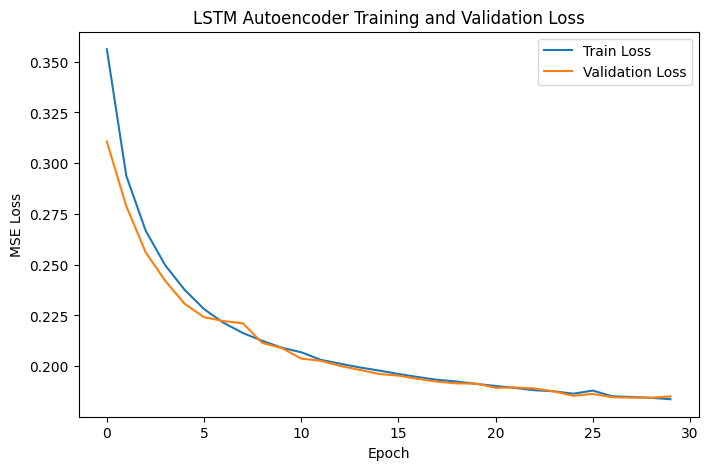

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Autoencoder Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

625/625 [==============================] - 6s 8ms/step


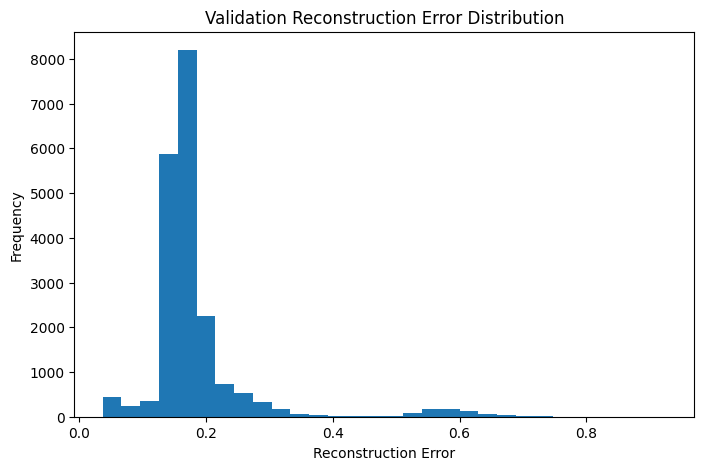

In [ ]:
X_val_pred = model.predict(X_val)
val_mse = np.mean(np.power(X_val - X_val_pred, 2), axis=(1, 2))

plt.figure(figsize=(8, 5))
plt.hist(val_mse, bins=30)
plt.title("Validation Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()

In [ ]:
threshold = val_mse.mean() + 3 * val_mse.std()

print("Threshold:", threshold)
print("Mean reconstruction error:", val_mse.mean())
print("Std reconstruction error:", val_mse.std())

Threshold: 0.4593774750828743
Mean reconstruction error: 0.18514054
Std reconstruction error: 0.09141231


In [ ]:


anomaly_flags = val_mse > threshold

print("Potential anomalies found:", anomaly_flags.sum())
print("Total validation sequences:", len(anomaly_flags))
print("Percentage flagged:", (anomaly_flags.sum() / len(anomaly_flags)) * 100, "%")

Potential anomalies found: 756
Total validation sequences: 20000
Percentage flagged: 3.7800000000000002 %


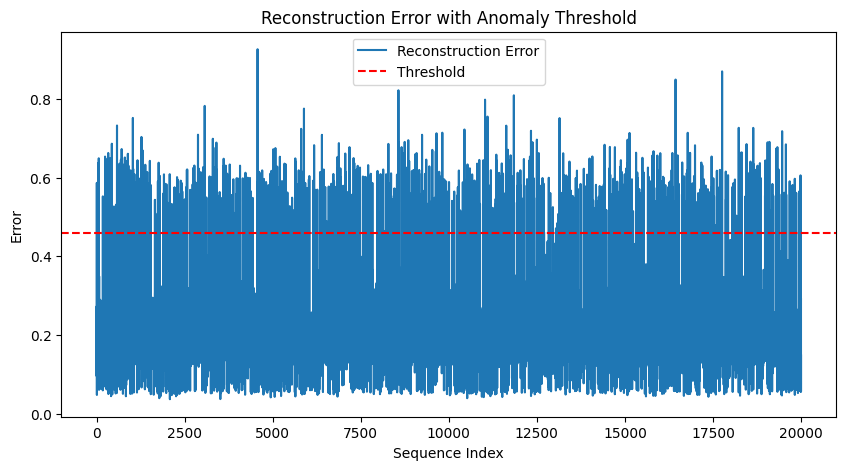

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(val_mse, label="Reconstruction Error")
plt.axhline(threshold, color="red", linestyle="--", label="Threshold")
plt.title("Reconstruction Error with Anomaly Threshold")
plt.xlabel("Sequence Index")
plt.ylabel("Error")
plt.legend()
plt.show()

In [ ]:
import joblib

model.save("lstm_autoencoder_te.h5")
joblib.dump(scaler, "scaler_te.pkl")

['scaler_te.pkl']